# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor


url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [2]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [4]:
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


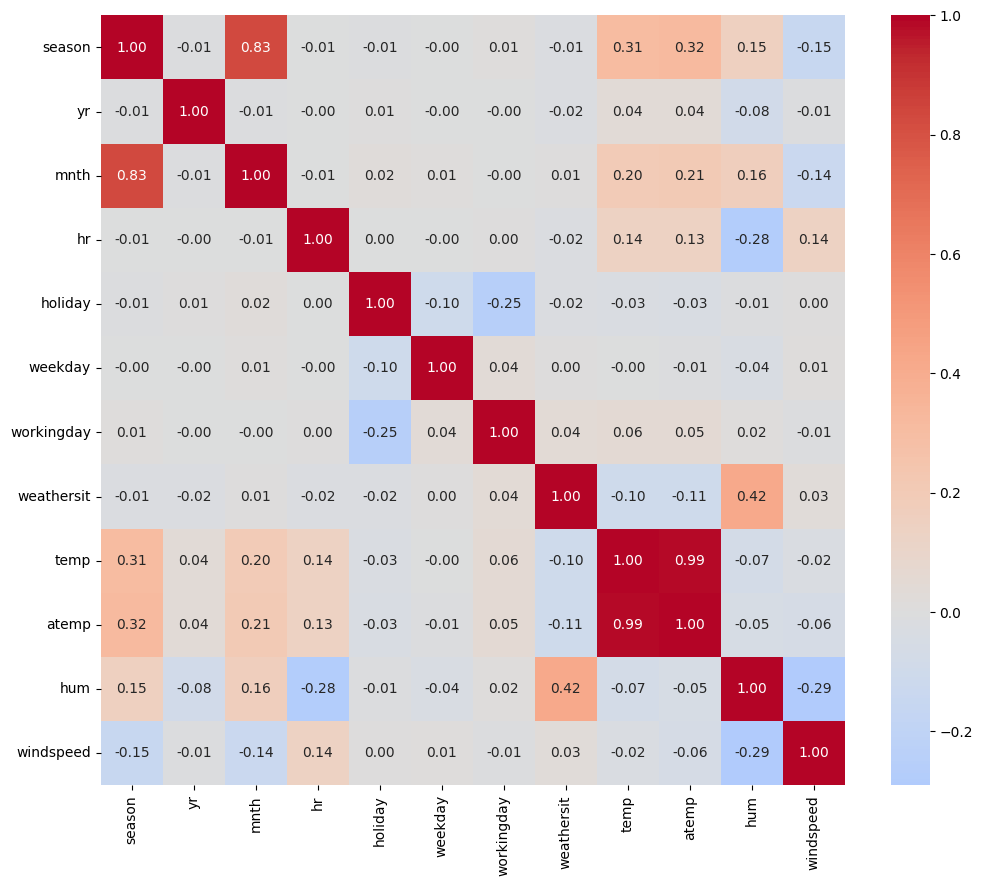

In [5]:
# Your code here
# Remove variables that should not be predictors

target = 'cnt'

X = df.copy()
y = df[target].astype(float)


X.drop(
    columns=[
        'cnt', #since it is the target
        'casual', #gives direct info about cnt
        'registered', #gives direct info about cnt
        'instant', #works as an identifier and has nothing to do with cnt value
        'dteday' #dataset already gives info through yr, mnth and weekday
    ],
    inplace=True
)

#correlation matrix
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)

plt.show()

In [6]:
X.drop(columns=['atemp'], inplace=True) #atemp and temp are too correlated

In [7]:
#one-hot encode categorical variables
categorical_features = [
    'season',
    'mnth',
    'hr',
    'weekday',
    'weathersit'
]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print(X.shape)
print(X.head())

(17379, 52)
   yr  holiday  workingday  temp   hum  windspeed  season_2  season_3  \
0   0        0           0  0.24  0.81        0.0     False     False   
1   0        0           0  0.22  0.80        0.0     False     False   
2   0        0           0  0.22  0.80        0.0     False     False   
3   0        0           0  0.24  0.75        0.0     False     False   
4   0        0           0  0.24  0.75        0.0     False     False   

   season_4  mnth_2  ...  hr_23  weekday_1  weekday_2  weekday_3  weekday_4  \
0     False   False  ...  False      False      False      False      False   
1     False   False  ...  False      False      False      False      False   
2     False   False  ...  False      False      False      False      False   
3     False   False  ...  False      False      False      False      False   
4     False   False  ...  False      False      False      False      False   

   weekday_5  weekday_6  weathersit_2  weathersit_3  weathersit_4  
0     

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [9]:
# Your code here
#XGBoost

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}


grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print("Best parameters:")
print(grid_search.best_params_)
print("Best CV RMSE:")
print(-grid_search.best_score_)
best_xgb_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE:
49.8047076154458


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [10]:
y_pred = best_xgb_model.predict(X_test)

In [13]:
#linear regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [14]:
# Your code here
# Make predictions on the test data
xgb_predictions = best_xgb_model.predict(X_test)
linear_predictions = linear_model.predict(X_test)
print(xgb_predictions[:10])
print(linear_predictions[:10])

[396.72882    65.71571     1.9445301 540.05817    39.099964   74.86466
 741.05133    14.102387    3.736961   29.574743 ]
[454.29926328 163.7035209    6.34603788 433.80942505 -65.59604391
 -26.98871037 531.88386833 145.79252417  60.06434169  28.30228322]


In [15]:
# XGBoost
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

# Linear Regression
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

print("XGBoost")
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R²:", xgb_r2)

print("\nLinear Regression")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R²:", linear_r2)

XGBoost
MSE: 2392.2827775851865
RMSE: 48.9109678659622
MAE: 31.117705995330567
R²: 0.9244512331715418

Linear Regression
MSE: 10100.659726660497
RMSE: 100.50203842042457
MAE: 74.09536674592364
R²: 0.681019153064609


In [16]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'Linear Regression'],
    'MSE': [xgb_mse, linear_mse],
    'RMSE': [xgb_rmse, linear_rmse],
    'MAE': [xgb_mae, linear_mae],
    'R²': [xgb_r2, linear_r2]
})

results

,Model,MSE,RMSE,MAE,R²
0,XGBoost,2392.282778,48.910968,31.117706,0.924451
1,Linear Regression,10100.659727,100.502038,74.095367,0.681019


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

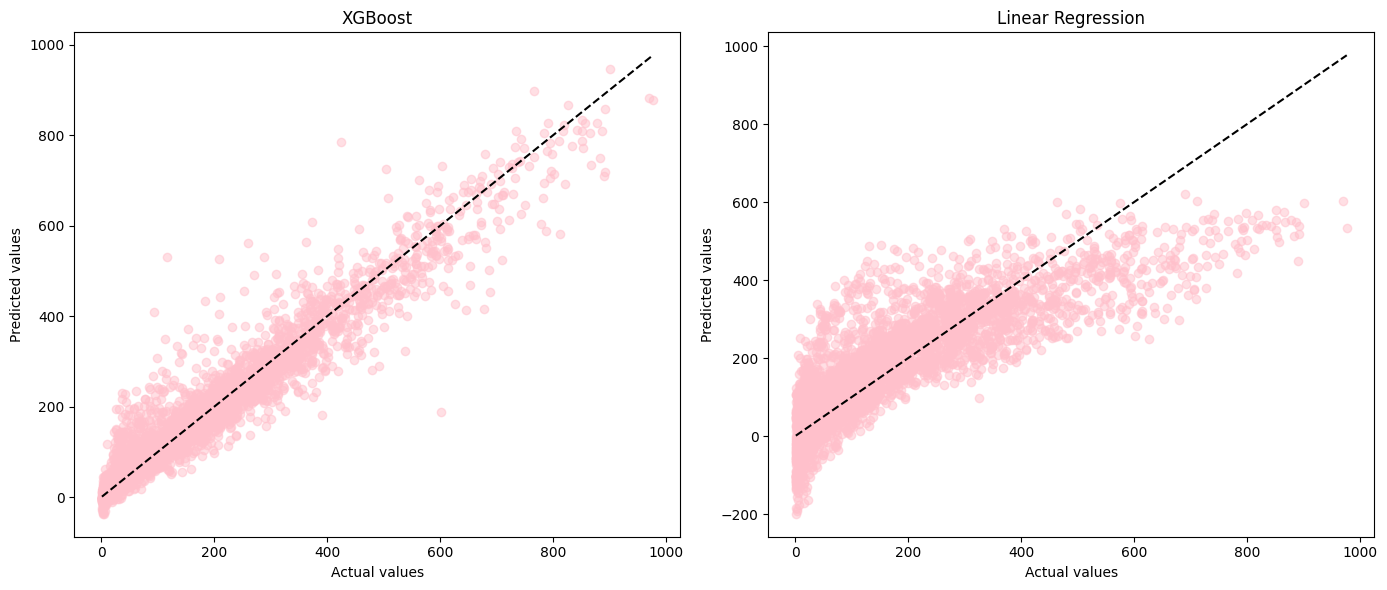

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost
axes[0].scatter(
    y_test,
    xgb_predictions,
    alpha=0.5,
    color='pink'
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='black'
)

axes[0].set_xlabel('Actual values')
axes[0].set_ylabel('Predicted values')
axes[0].set_title('XGBoost')


# Linear Regression
axes[1].scatter(
    y_test,
    linear_predictions,
    alpha=0.5,
    color='pink'
)

axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    color='black'
)

axes[1].set_xlabel('Actual values')
axes[1].set_ylabel('Predicted values')
axes[1].set_title('Linear Regression')


plt.tight_layout()
plt.show()

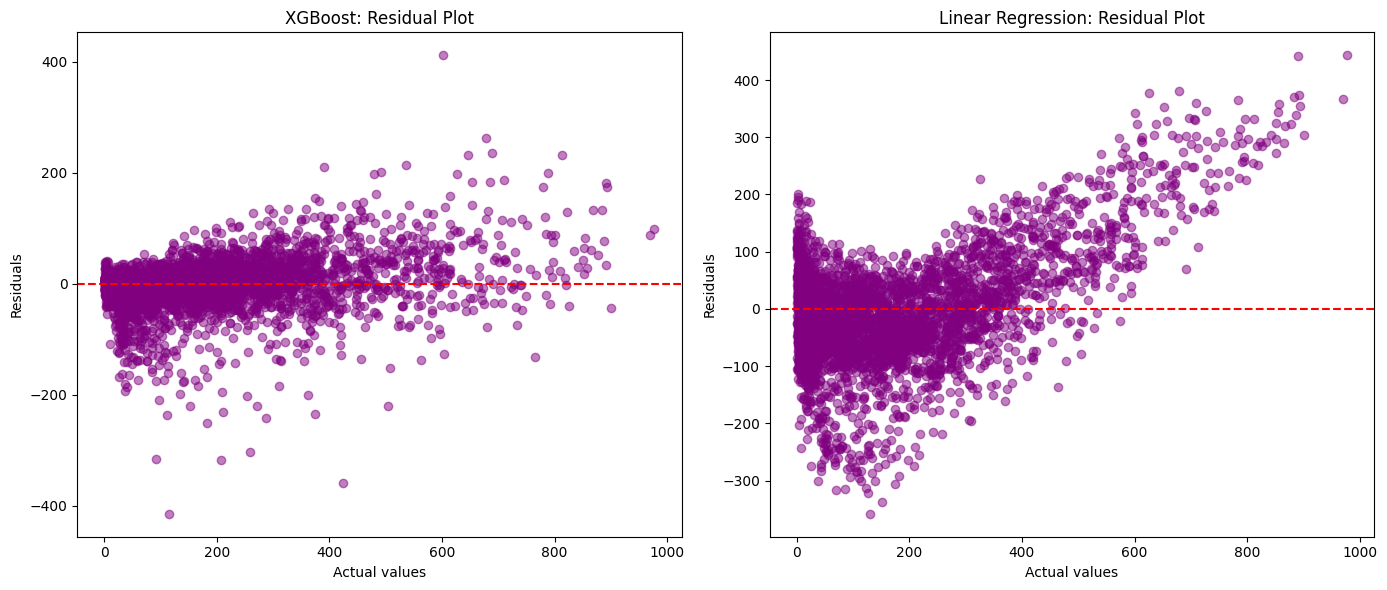

In [18]:
xgb_residuals = y_test - xgb_predictions
linear_residuals = y_test - linear_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

residuals = [xgb_residuals, linear_residuals]
titles = ['XGBoost', 'Linear Regression']

for ax, res, title in zip(axes, residuals, titles):
    ax.scatter(y_test, res, alpha=0.5, color='purple')
    ax.axhline(0, linestyle='--', color="red")
    ax.set_xlabel('Actual values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{title}: Residual Plot')

plt.tight_layout()
plt.show()